In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


(np.float64(-0.5), np.float64(1487.5), np.float64(1151.5), np.float64(-0.5))

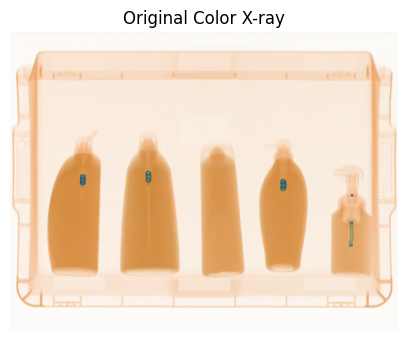

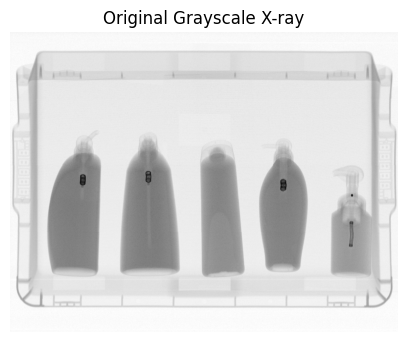

In [2]:
# Path to your X-ray image
IMAGE_PATH = "../../data/raw/Stage1/Color/2026-01-21_10-37-50-052.png"  # <-- change this

# Read image (OpenCV loads as BGR)
img_bgr = cv2.imread(IMAGE_PATH)

if img_bgr is None:
    raise FileNotFoundError("Image not found. Check the IMAGE_PATH.")

# Convert to grayscale (recommended for X-ray)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Convert BGR → RGB ONLY for visualization
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img_rgb)
plt.title("Original Color X-ray")
plt.axis("off")

plt.figure(figsize=(5,5))
plt.imshow(img_gray, cmap="gray")
plt.title("Original Grayscale X-ray")
plt.axis("off")


(np.float64(-0.5), np.float64(1487.5), np.float64(1151.5), np.float64(-0.5))

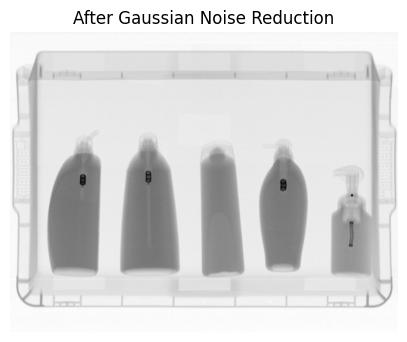

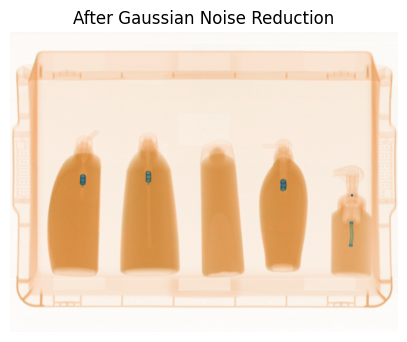

In [3]:
# Gaussian Blur to reduce sensor noise
# Kernel size must be odd (5,5) is standard
img_denoised = cv2.GaussianBlur(
    img_gray,
    ksize=(5, 5),
    sigmaX=0
)

plt.figure(figsize=(5,5))
plt.imshow(img_denoised, cmap="gray")
plt.title("After Gaussian Noise Reduction")
plt.axis("off")

img_denoised_rgb = cv2.GaussianBlur(
    img_rgb,
    ksize=(5, 5),
    sigmaX=0
)

plt.figure(figsize=(5,5))
plt.imshow(img_denoised_rgb)
plt.title("After Gaussian Noise Reduction")
plt.axis("off")


(np.float64(-0.5), np.float64(1487.5), np.float64(1151.5), np.float64(-0.5))

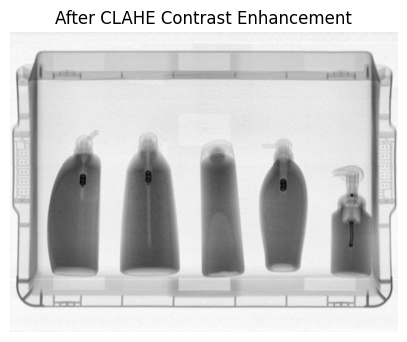

In [4]:
# Create CLAHE object
clahe = cv2.createCLAHE(
    clipLimit=2.0,      # controls contrast strength
    tileGridSize=(8,8)  # local regions
)

img_clahe = clahe.apply(img_denoised)

plt.figure(figsize=(5,5))
plt.imshow(img_clahe, cmap="gray")
plt.title("After CLAHE Contrast Enhancement")
plt.axis("off")




(np.float64(-0.5), np.float64(1487.5), np.float64(1151.5), np.float64(-0.5))

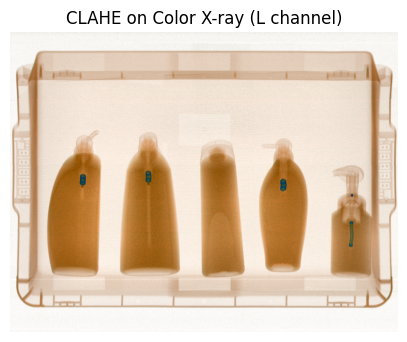

In [5]:
# img_bgr is your original image
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(img_lab)

# Ensure correct dtype
l = l.astype(np.uint8)

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

l_clahe = clahe.apply(l)

# Merge channels back
img_lab_clahe = cv2.merge((l_clahe, a, b))
img_clahe_rgb = cv2.cvtColor(img_lab_clahe, cv2.COLOR_LAB2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img_clahe_rgb)
plt.title("CLAHE on Color X-ray (L channel)")
plt.axis("off")


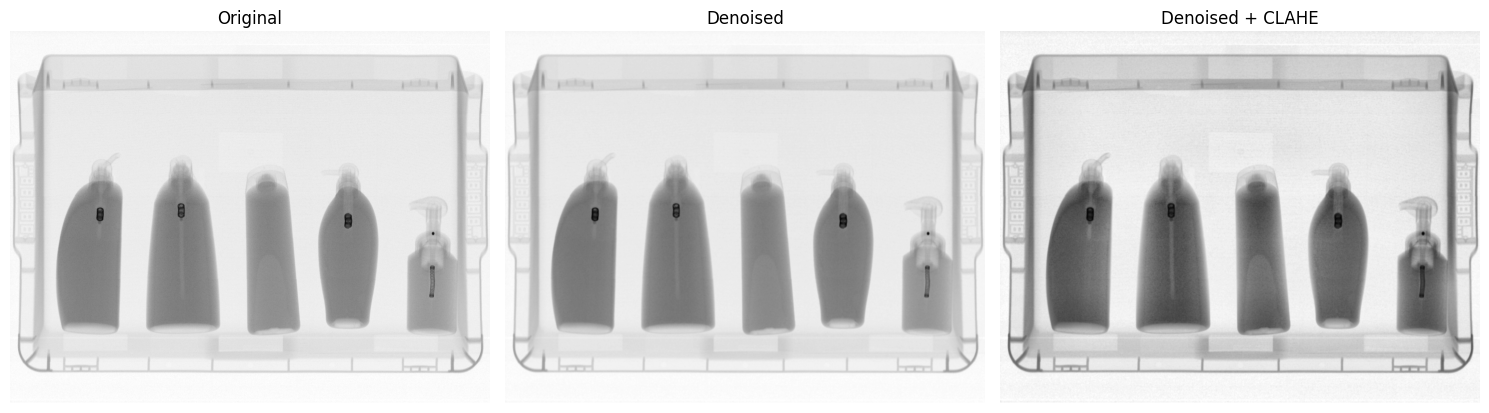

In [6]:
titles = ["Original", "Denoised", "Denoised + CLAHE"]
images = [img_gray, img_denoised, img_clahe]

plt.figure(figsize=(15,5))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# --- Load image
IMAGE_PATH = "../../data/test/2026-01-27_11-38-51-663.png"
img_bgr = cv2.imread(IMAGE_PATH)

if img_bgr is None:
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")


# 1) GRAYSCALE IMG

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Denoise (Gaussian)
gray_denoised = cv2.GaussianBlur(img_gray, (5, 5), 0)

# CLAHE (single-channel only)
clahe_gray = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
gray_clahe = clahe_gray.apply(gray_denoised.astype(np.uint8))


# 2) COLOR IMG (LAB + CLAHE on L)

# Original for display (RGB)
rgb_original = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Denoise color (Gaussian on BGR)
bgr_denoised = cv2.GaussianBlur(img_bgr, (5, 5), 0)
rgb_denoised = cv2.cvtColor(bgr_denoised, cv2.COLOR_BGR2RGB)

# CLAHE on luminance (L channel in LAB)
lab = cv2.cvtColor(bgr_denoised, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

clahe_color = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
l_clahe = clahe_color.apply(l.astype(np.uint8))

lab_clahe = cv2.merge((l_clahe, a, b))
rgb_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)


# VISUALIZE: 2 rows × 3 cols

titles_gray = ["Grayscale (Original)", "Grayscale (Denoised)", "Grayscale (Denoised + CLAHE)"]
images_gray = [img_gray, gray_denoised, gray_clahe]

titles_color = ["Color (Original)", "Color (Denoised)", "Color (Denoised + CLAHE on L)"]
images_color = [rgb_original, rgb_denoised, rgb_clahe]

plt.figure(figsize=(18, 10))

# Row 1: Grayscale
for i in range(3):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images_gray[i], cmap="gray")
    plt.title(titles_gray[i])
    plt.axis("off")

# Row 2: Color
for i in range(3):
    plt.subplot(2, 3, 3 + i + 1)
    plt.imshow(images_color[i])
    plt.title(titles_color[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

# =========================
# SAVE OUTPUTS
# =========================

OUT_DIR = "../../data/test/processed"
os.makedirs(OUT_DIR, exist_ok=True)

# 1) Save color denoised (Gaussian only)
color_denoised_bgr = bgr_denoised  # already BGR
denoised_path = f"{OUT_DIR}/2026-01-27_11-38-51-663_color_denoised.png"
cv2.imwrite(denoised_path, color_denoised_bgr)

# 2) Save color CLAHE (LAB → BGR)
color_clahe_bgr = cv2.cvtColor(rgb_clahe, cv2.COLOR_RGB2BGR)
clahe_path = f"{OUT_DIR}/2026-01-27_11-38-51-663_color_clahe.png"
cv2.imwrite(clahe_path, color_clahe_bgr)

print("Saved files:")
print(" -", denoised_path)
print(" -", clahe_path)



: 

Loop through folder + visualize (QA mode)

Found 5 images
[1/5] Processing 2026-01-21_10-37-50-052.png


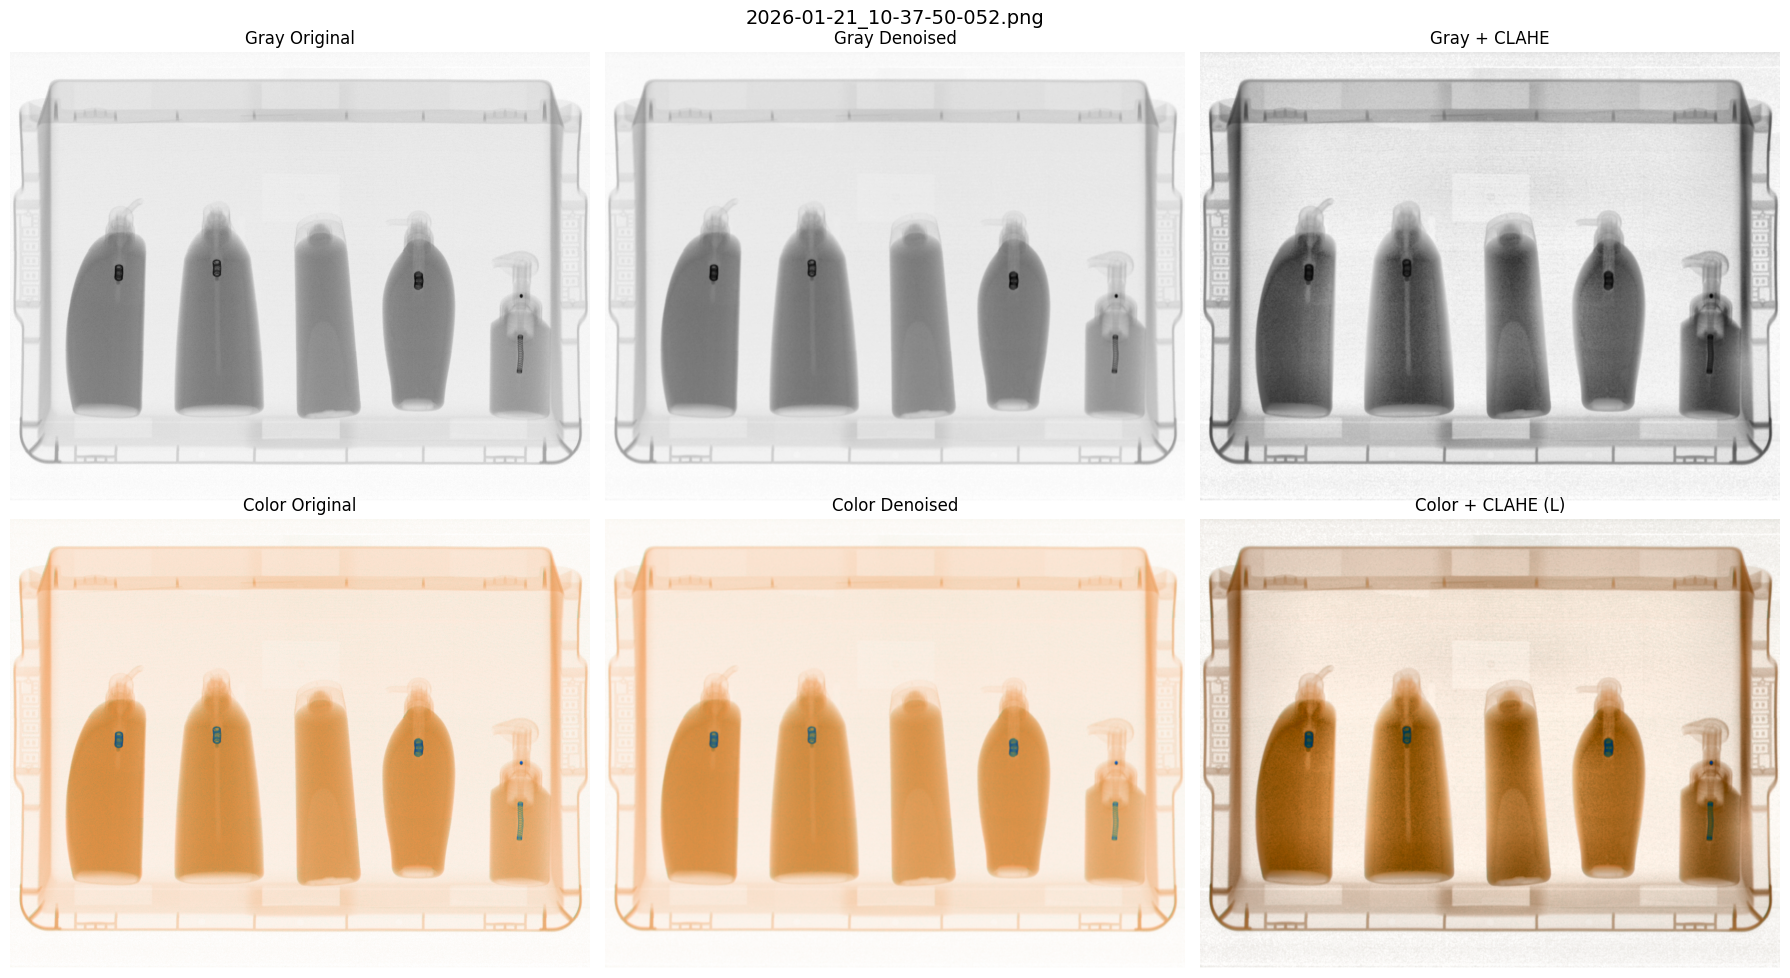

[2/5] Processing 2026-01-21_10-38-24-999.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -------- Paths --------
INPUT_DIR = Path("../../data/raw/Stage1/Color")
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tiff"}

# -------- CLAHE configs --------
clahe_gray = cv2.createCLAHE(clipLimit=3.5, tileGridSize=(8, 8))
clahe_color = cv2.createCLAHE(clipLimit=3.5, tileGridSize=(8, 8))

# -------- Loop images --------
image_paths = sorted([p for p in INPUT_DIR.iterdir() if p.suffix.lower() in IMAGE_EXTS])[:5]

print(f"Found {len(image_paths)} images")

for idx, img_path in enumerate(image_paths):
    print(f"[{idx+1}/{len(image_paths)}] Processing {img_path.name}")

    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        print(" Skipped (cannot read)")
        continue

    # =========================
    # 1) GRAYSCALE PIPELINE
    # =========================
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray_denoised = cv2.GaussianBlur(img_gray, (5, 5), 0)
    gray_clahe = clahe_gray.apply(gray_denoised.astype(np.uint8))

    # =========================
    # 2) COLOR PIPELINE
    # =========================
    rgb_original = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    bgr_denoised = cv2.GaussianBlur(img_bgr, (5, 5), 0)
    rgb_denoised = cv2.cvtColor(bgr_denoised, cv2.COLOR_BGR2RGB)

    lab = cv2.cvtColor(bgr_denoised, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l_clahe = clahe_color.apply(l.astype(np.uint8))
    lab_clahe = cv2.merge((l_clahe, a, b))
    rgb_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

    # =========================
    # VISUALIZE (2 × 3)
    # =========================
    plt.figure(figsize=(18, 10))

    titles_gray = ["Gray Original", "Gray Denoised", "Gray + CLAHE"]
    images_gray = [img_gray, gray_denoised, gray_clahe]

    titles_color = ["Color Original", "Color Denoised", "Color + CLAHE (L)"]
    images_color = [rgb_original, rgb_denoised, rgb_clahe]

    for i in range(3):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images_gray[i], cmap="gray")
        plt.title(titles_gray[i])
        plt.axis("off")

    for i in range(3):
        plt.subplot(2, 3, 3 + i + 1)
        plt.imshow(images_color[i])
        plt.title(titles_color[i])
        plt.axis("off")

    plt.suptitle(img_path.name, fontsize=14)
    plt.tight_layout()
    plt.show()


Batch processing + save (Production mode)

In [ ]:
from pathlib import Path
import cv2
import numpy as np

INPUT_DIR = Path("../../data/raw/Stage1/Color")
OUT_GRAY = Path("../../data/interim/Stage1/gray_clahe")
OUT_COLOR = Path("../../data/interim/Stage1/color_clahe")

OUT_GRAY.mkdir(parents=True, exist_ok=True)
OUT_COLOR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tiff"}

clahe_gray = cv2.createCLAHE(clipLimit=4.5, tileGridSize=(8, 8))
clahe_color = cv2.createCLAHE(clipLimit=4.5, tileGridSize=(8, 8))

image_paths = [p for p in INPUT_DIR.iterdir() if p.suffix.lower() in IMAGE_EXTS]

for img_path in image_paths:
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        continue

    # ---- Grayscale ----
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    gray = clahe_gray.apply(gray.astype(np.uint8))

    cv2.imwrite(str(OUT_GRAY / img_path.name), gray)

    # ---- Color (LAB + CLAHE on L) ----
    bgr = cv2.GaussianBlur(img_bgr, (5, 5), 0)
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l = clahe_color.apply(l.astype(np.uint8))
    lab = cv2.merge((l, a, b))
    color = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    cv2.imwrite(str(OUT_COLOR / img_path.name), color)

print("Batch preprocessing complete")


✅ Batch preprocessing complete


RESIZING + DATA AUGMENTATION

Data flipping and augmentation for more data

In [ ]:
from pathlib import Path
import cv2
import numpy as np
import random
import re
from collections import defaultdict

# =========================
# Config
# =========================
INPUT_DIR = Path("../../data/raw/Stage1/Color")

# Output (augmented images)
OUT_GRAY  = Path("../../data/interim/Stage1/gray_clahe_1500x1000_noborder_aug")
OUT_COLOR = Path("../../data/interim/Stage1/color_clahe_1500x1000_noborder_aug")

# ALSO create a grouping map so you can split without leakage later
GROUPS_JSON_GRAY  = OUT_GRAY  / "groups.json"
GROUPS_JSON_COLOR = OUT_COLOR / "groups.json"

OUT_GRAY.mkdir(parents=True, exist_ok=True)
OUT_COLOR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tiff"}
TARGET_SIZE = (1500, 1000)  # (width, height)

# How many augmented copies to save per original
N_AUG_PER_IMAGE = 4

# Seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

clahe_gray = cv2.createCLAHE(clipLimit=4.5, tileGridSize=(8, 8))
clahe_color = cv2.createCLAHE(clipLimit=4.5, tileGridSize=(8, 8))

# =========================
# Helpers
# =========================
def trim_black_borders(img, thresh=8):
    """
    Removes near-black borders by finding the bounding box of non-black pixels.
    Works for grayscale and BGR.
    """
    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    mask = gray > thresh
    coords = np.argwhere(mask)

    if coords.size == 0:
        return img

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]

def resize_crop_fill(img, target_size=(1500, 1000)):
    """
    Scale so the image fully covers target size, then center-crop.
    No padding -> no borders.
    """
    h, w = img.shape[:2]
    target_w, target_h = target_size

    scale = max(target_w / w, target_h / h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))

    interp = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_CUBIC
    resized = cv2.resize(img, (new_w, new_h), interpolation=interp)

    x0 = (new_w - target_w) // 2
    y0 = (new_h - target_h) // 2
    cropped = resized[y0:y0 + target_h, x0:x0 + target_w]
    return cropped

# =========================
# Augmentations (safe-ish for tray geometry)
# =========================
def random_affine(img, max_rotate=3.0, max_translate=0.02, max_scale=0.03):
    """
    Small rotation/translation/scale jitter.
    Uses border reflection to avoid black borders.
    """
    h, w = img.shape[:2]

    angle = random.uniform(-max_rotate, max_rotate)
    scale = random.uniform(1.0 - max_scale, 1.0 + max_scale)
    tx = random.uniform(-max_translate, max_translate) * w
    ty = random.uniform(-max_translate, max_translate) * h

    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    M[0, 2] += tx
    M[1, 2] += ty

    warped = cv2.warpAffine(
        img, M, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101
    )
    return warped

def random_gamma(img, gamma_range=(0.85, 1.15)):
    """
    Mild gamma shift. Works for gray or BGR.
    """
    gamma = random.uniform(*gamma_range)
    inv = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv) * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(img, table)

def random_noise(img, sigma_range=(2, 8)):
    """
    Add small gaussian noise.
    """
    sigma = random.uniform(*sigma_range)
    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    out = img.astype(np.float32) + noise
    out = np.clip(out, 0, 255).astype(np.uint8)
    return out

def random_flip(img):
    """
    Scanner-safe flips.
    Horizontal flip only (disable vertical unless physically valid).
    """
    out = img
    if random.random() < 0.5:
        out = cv2.flip(out, 1)  # horizontal flip
    return out

def augment(img):
    out = random_flip(img)
    out = random_affine(
        out,
        max_rotate=2.0,
        max_translate=0.015,
        max_scale=0.02
    )
    out = random_gamma(out, gamma_range=(0.9, 1.1))
    out = random_noise(out, sigma_range=(2, 6))
    return out

def stem_no_ext(p: Path) -> str:
    return p.stem

def ensure_uint8(img):
    if img.dtype != np.uint8:
        img = np.clip(img, 0, 255).astype(np.uint8)
    return img

# =========================
# MAIN: preprocess + save + write grouping map
# =========================
image_paths = sorted([p for p in INPUT_DIR.iterdir() if p.suffix.lower() in IMAGE_EXTS])
print(f"Found {len(image_paths)} raw images in {INPUT_DIR}")

# group maps: base_name -> list of generated filenames
groups_gray = defaultdict(list)
groups_color = defaultdict(list)

for img_path in image_paths:
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        print(f"Could not read: {img_path}")
        continue

    # trim borders
    img_bgr = trim_black_borders(img_bgr, thresh=8)

    # ---- Build base grayscale ----
    gray_base = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray_base = cv2.GaussianBlur(gray_base, (5, 5), 0)
    gray_base = clahe_gray.apply(ensure_uint8(gray_base))
    gray_base = resize_crop_fill(gray_base, TARGET_SIZE)

    # ---- Build base color (LAB + CLAHE on L) ----
    bgr_base = cv2.GaussianBlur(img_bgr, (5, 5), 0)
    lab = cv2.cvtColor(bgr_base, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l = clahe_color.apply(ensure_uint8(l))
    lab = cv2.merge((l, a, b))
    color_base = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    color_base = resize_crop_fill(color_base, TARGET_SIZE)

    # ---- Save originals + augs, and record group membership ----
    base_name = stem_no_ext(img_path)

    # Save original
    gray_name = f"{base_name}_orig.png"
    color_name = f"{base_name}_orig.png"

    cv2.imwrite(str(OUT_GRAY / gray_name), gray_base)
    cv2.imwrite(str(OUT_COLOR / color_name), color_base)

    groups_gray[base_name].append(gray_name)
    groups_color[base_name].append(color_name)

    # Save augmented copies
    for i in range(N_AUG_PER_IMAGE):
        gray_aug = augment(gray_base)
        color_aug = augment(color_base)

        # enforce final size
        gray_aug = resize_crop_fill(gray_aug, TARGET_SIZE)
        color_aug = resize_crop_fill(color_aug, TARGET_SIZE)

        gray_aug_name = f"{base_name}_aug{i:02d}.png"
        color_aug_name = f"{base_name}_aug{i:02d}.png"

        cv2.imwrite(str(OUT_GRAY / gray_aug_name), gray_aug)
        cv2.imwrite(str(OUT_COLOR / color_aug_name), color_aug)

        groups_gray[base_name].append(gray_aug_name)
        groups_color[base_name].append(color_aug_name)

# Save grouping maps (so your split script can keep siblings together)
import json
from datetime import datetime

with open(GROUPS_JSON_GRAY, "w") as f:
    json.dump({
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "source_raw": str(INPUT_DIR),
        "out_dir": str(OUT_GRAY),
        "seed": SEED,
        "n_aug_per_image": N_AUG_PER_IMAGE,
        "group_key": "base_name (raw filename stem)",
        "groups": groups_gray,
    }, f, indent=2)

with open(GROUPS_JSON_COLOR, "w") as f:
    json.dump({
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "source_raw": str(INPUT_DIR),
        "out_dir": str(OUT_COLOR),
        "seed": SEED,
        "n_aug_per_image": N_AUG_PER_IMAGE,
        "group_key": "base_name (raw filename stem)",
        "groups": groups_color,
    }, f, indent=2)

print("Preprocessing + augmentation complete")
print(f"Group maps saved:\n - {GROUPS_JSON_GRAY}\n - {GROUPS_JSON_COLOR}")
print(f"Total groups (raw originals): {len(groups_color)}")
print(f"Total augmented images (color): {sum(len(v) for v in groups_color.values())}")

Found 175 raw images in ../../data/raw/Stage1/Color
Preprocessing + augmentation complete
Group maps saved:
 - ../../data/interim/Stage1/gray_clahe_1500x1000_noborder_aug/groups.json
 - ../../data/interim/Stage1/color_clahe_1500x1000_noborder_aug/groups.json
Total groups (raw originals): 175
Total augmented images (color): 525
